# **Práctica 1**: *Minería de Textos y Análisis de Sentimientos*
 **Asignatura**: Minería de Textos y Modelos de Lenguaje

<div style="display: flex; justify-content: space-between; align-items: center; width: 100%;"> <div> <img src="../logo_uclm.png" alt="Logo UCLM" width="300"> </div> <div style="text-align: right;"> <strong>Autores:</strong><br> Antonio Carrascosa Jiménez<br> Iván Román Utrilla </div> </div>

## ****Introducción****

En esta práctica abordamos un flujo completo de Minería de Textos y Análisis de Sentimientos aplicado a un conjunto de datos compuesto por t etiquetados con polaridad positiva o negativa.

Se entrenarán y evaluarán distintos modelos de clasificación supervisada utilizando tanto un esquema de validación por retención (80/20) como validación cruzada estratificada. Finalmente, se analizará el rendimiento de los modelos, la influencia de las decisiones de preprocesamiento y la estabilidad de los resultados.


## ****0. Preparativos****
Comenzaremos cargando todas las librerías que serán necesarias durante el desarrollo de la práctica. También, se fijará una semilla para la reproducibilidad del entrenamiento de los modelos.

In [70]:
import pandas as pd
import numpy as np
import spacy
import limpieza_canonica
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from collections import Counter
seed = 42

## ****1. Carga y preparación inicial del conjunto de datos****
En este primer apartado cargaremos el conjunto de datos dado a partir de un csv utilizando pandas. Seguidamente, seleccionaremos aquellas variables con las cuales trabajaremos (`text` y `polarity`) y las convertiremos en una *serie*. Adicionalmente, aplicamos una transformación a la variable `polarity`:
- "negativo": 0
- "positivo": 1

Por último, mostraremos una gráfica que nos permitirá analizar el desbalanceo de la variable objetivo, para determinar si una validación estratificada es coherente para el problema.

In [71]:
df_original = pd.read_csv("sentiment_analysis_dataset_polarity.csv")

corpus_text = df_original["text"] # Variable de texto a utilizar para el análisis de sentimiento
polarity = df_original["polarity"] # Variable objetivo

polarity = polarity.map({"negativo": 0, "positivo": 1})

df_procesado = pd.DataFrame({ "text": corpus_text, "polarity": polarity }) 
df_procesado.sample(10, random_state=seed)

,text,polarity
1179,Extraño esa figura en la casa que estaba atent...,1
1204,"ni modo, tocó independizarse rápido",1
2576,"A los de JxC, y ""Periodistas"" que estan defend...",1
422,Después de varios comentarios agrios y hate re...,0
695,"no me extraña que se hayan alejado amistades, ...",0
194,"Hay varias pero, pq sigo sintiéndome infeliz, ...",0
296,Gordo Dan me parece un tipo asquerosamente fac...,0
1554,"una pena lo de oklahoma, revivieron muy muy ta...",1
1210,Que tiene como casi dos horas viéndose la espa...,1
173,Me regalaron dos rosas bonitas 💕 fue muy bonit...,0


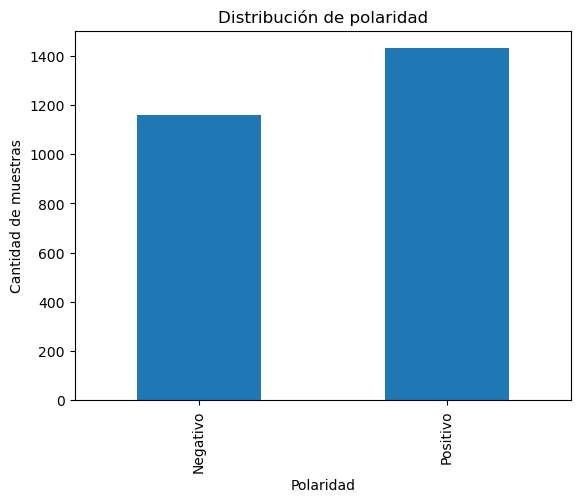

Difencia de  23.275862068965516 % entre negativos y positivos


In [72]:
counts = df_procesado["polarity"].value_counts(ascending = True)

counts.plot(kind="bar")
plt.title("Distribución de polaridad")
plt.xlabel("Polaridad")
plt.ylabel("Cantidad de muestras")
plt.xticks(ticks=[0, 1], labels=["Negativo", "Positivo"])
plt.show()

dif = (counts[1]-counts[0])/counts[0]

print("Difencia de ",dif*100, "% entre negativos y positivos")

Como podemos apreciar en la gráfica y en el resultado del cálculo, la diferencia en la cantidad de registros entre ambas etiquetas es superior al 20%, por lo que aplicar validación estratificada es muy recomendable.

## ****2. Preprocesado y limpieza del texto****

En este segundo apartado, relizaremos la limpieza de datos necesaria y usaremos `spacy` para analizar las palabras vacías (*stop_words*) que componen nuestro conjunto de datos. Primeramente, ahoremos un estudio sobre las palabras vacías que posee la variable `text`...

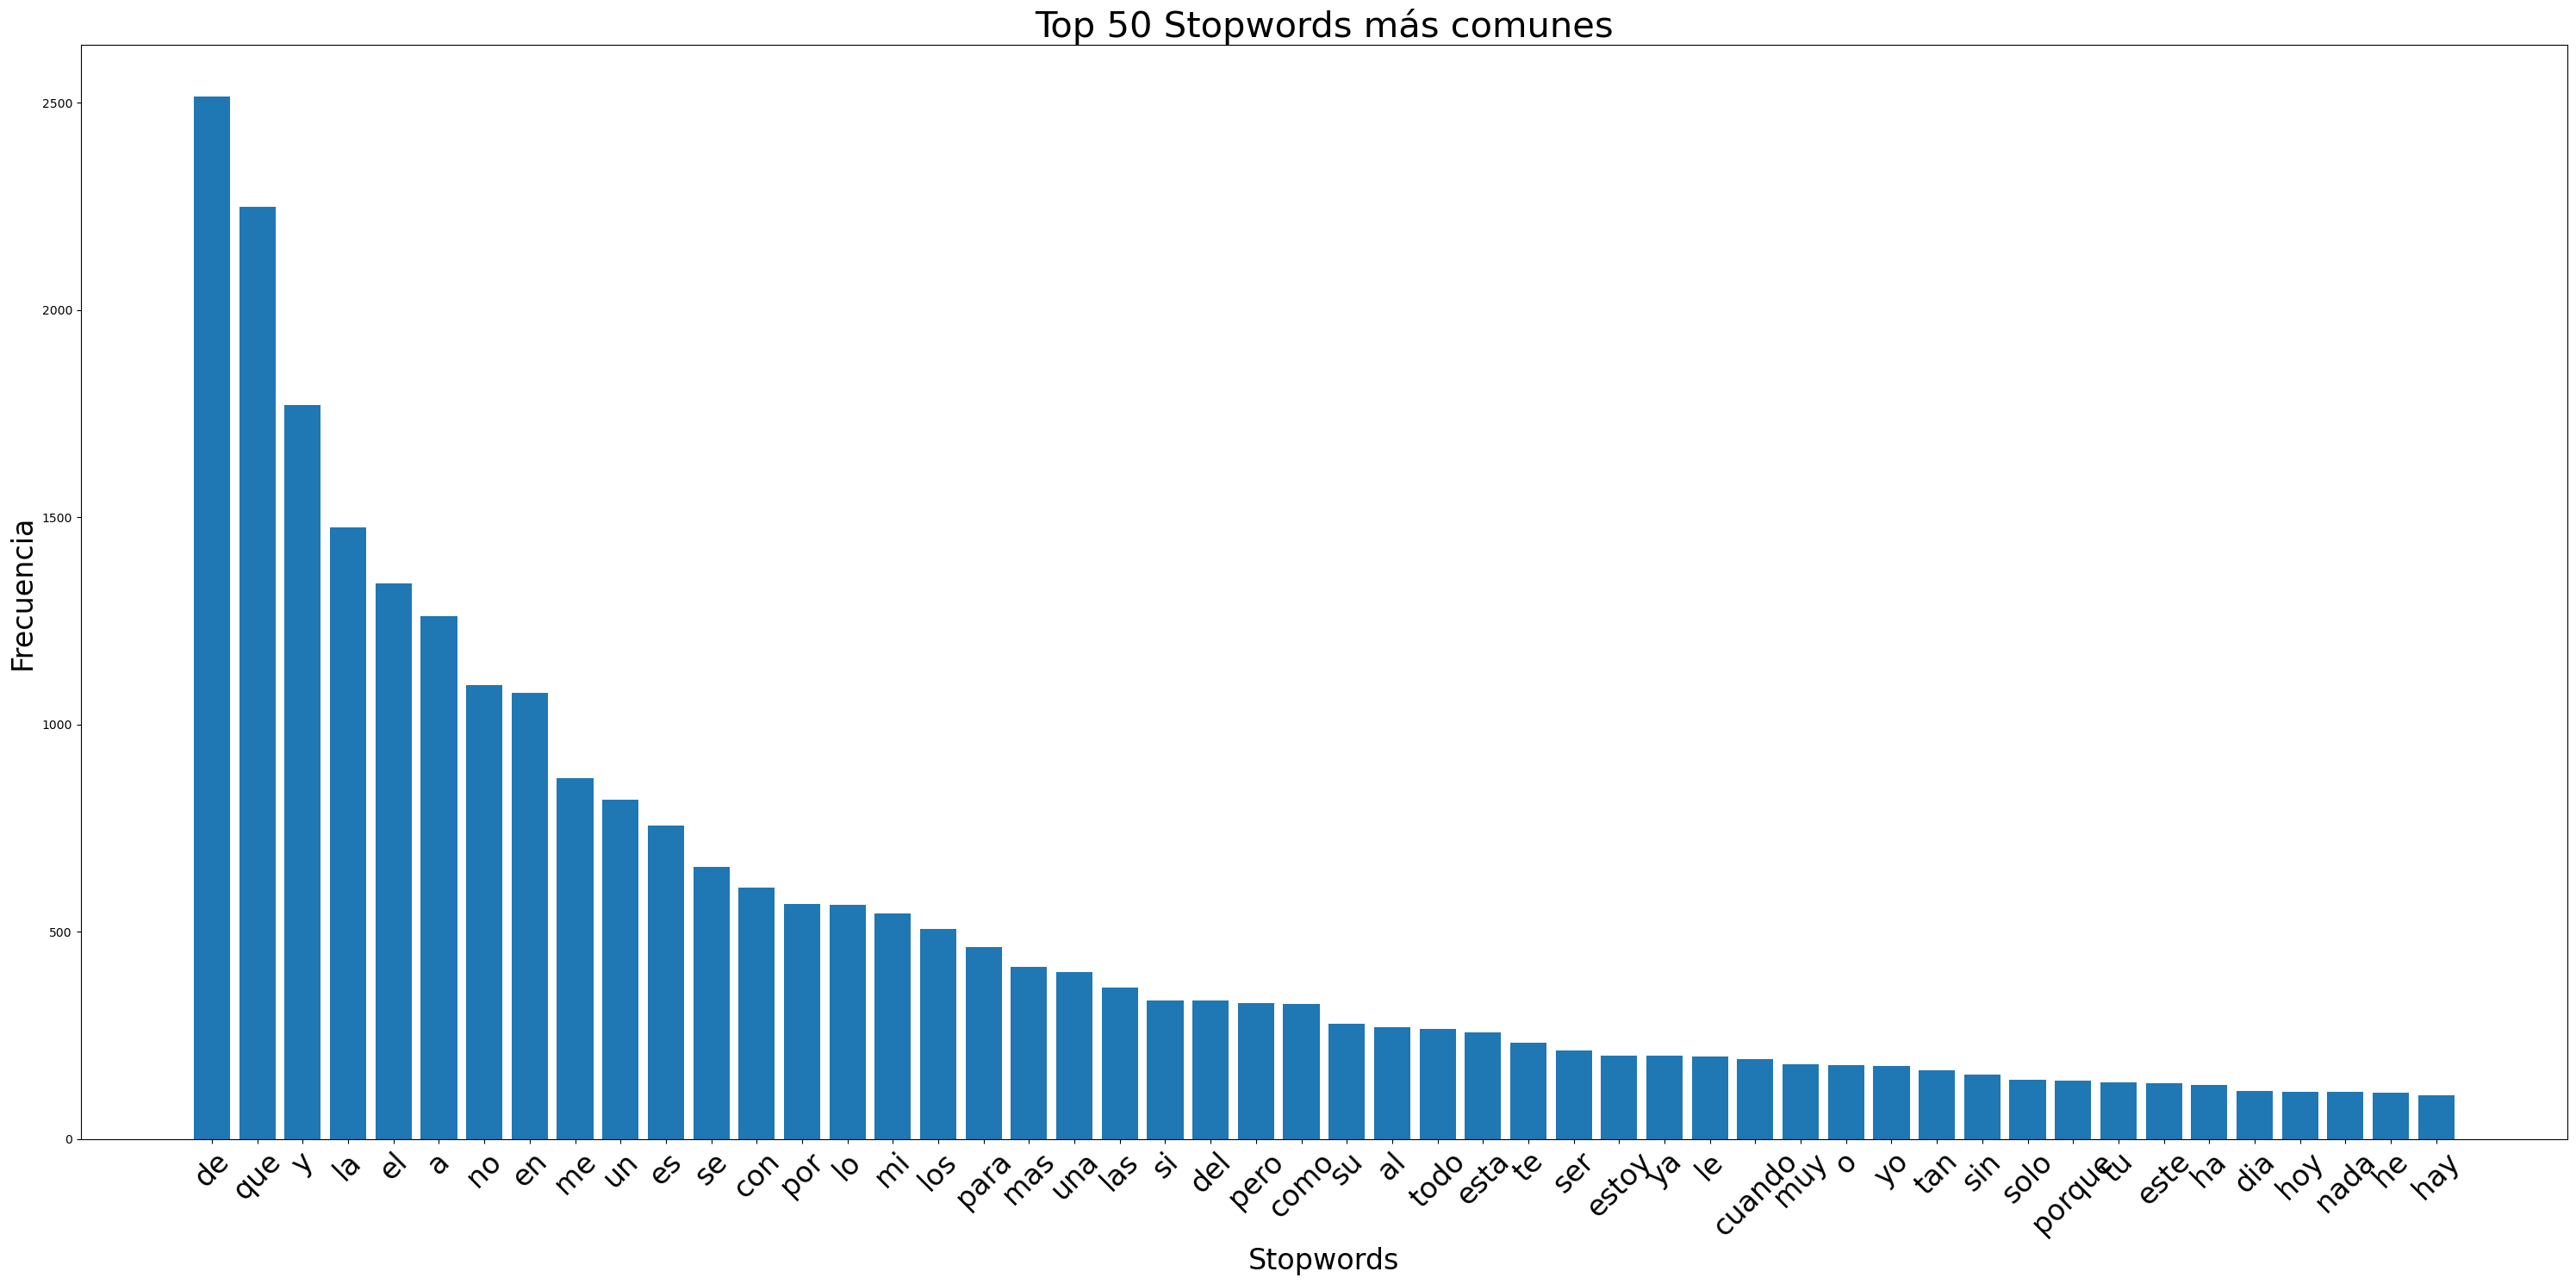

Hay un total de  388  palabras vacías distintas


In [73]:
nlp = spacy.load("es_core_news_sm") # Cargamos el modelo de lenguaje de spaCy para español
stopwords_freq = Counter() # Contador para almacenar la frecuencia de las palabras vacías

# eliminamos tildes, convertimos a minusculas y eliminamos caracteres especiales como ¡ ! , ( ) . ? ¿
df_procesado["text"] = df_procesado["text"].apply(limpieza_canonica.limpieza_canonica)

#extraemos las palabras vacias y contamos su frecuencia
contador = Counter()
for doc in nlp.pipe(df_procesado["text"].astype(str), batch_size=1000):
    contador.update(
        token.text.lower()
        for token in doc
        if token.is_stop 
    )

# Top 50 stopwords más frecuentes
top_50 = contador.most_common(50)
palabras = [w for w, _ in top_50]
frecuencias = [f for _, f in top_50]

plt.figure(figsize=(30, 15))
plt.bar(palabras, frecuencias)
plt.xticks(rotation=45, fontsize=24)
plt.xlabel("Stopwords", fontsize=24)
plt.ylabel("Frecuencia", fontsize=24)
plt.title("Top 50 Stopwords más comunes", fontsize=30)
plt.tight_layout()
plt.show()

print("Hay un total de ", len(contador), " palabras vacías distintas")

En circunstancias normales, la mayoría de estas palabras vacías podrían ser extraidas de las cadenas de texto en nuestro *corpus*, sin embargo, al estar realizando un análisis de sentimientos, palabras como *no*, *muy*, *tan* o *nada* no deben ser eliminadas, ya que estas, pueden aportar información crucial a la hora de realizar la clasificación de la `polarización`. De forma que, mantendremos las palabras no vacías y las palabras vacías que pueden aportar información relevante.

Específicamente, no se eliminaran las palabras vacías que aporten significado de negación (*no*, *ni*, *sin*...) ni conectores de contraste (*pero*, *aunque*, *tampoco*...). Tampoco se eliminarán emoticonos, ya que estos aportan una gran cantidada de información emocional.

In [74]:
palabras_vacias_relevantes = ["no", "ni", "nunca", "nadie", "nada", "ninguna", "ninguno", "tampoco", "sin", "sino",
                              "tan", "muy", "pero", "aunque", "embargo", "mientras"]

def filtrar_lemas(texto):
    doc = nlp(str(texto))
    tokens = []
    
    for token in doc:
        # Caso 1: emoticono o símbolo no alfabético pero no espacio
        if not token.is_alpha and not token.is_space:
            tokens.append(token.text)
            continue
        
        # Caso 2: palabra normal
        if (
            not token.is_stop
            or token.lemma_.lower() in palabras_vacias_relevantes
        ):
            tokens.append(token.lemma_.lower())
    return " ".join(tokens)

df_procesado_limpio = df_procesado["text"].apply(filtrar_lemas).to_frame(name="text")
display(df_procesado_limpio.sample(10, random_state=seed))

,text
1179,extraño figura casa atento resolvia ayudar mama
1204,ni tocar independizar él rapido
2576,jxc periodista defender justificamdo robo ataq...
422,comentario agrio hatir costco llegar conclusio...
695,no extrañar haber alejar amistad definitivamen...
194,pero pq sigo sintiendomir infeliz jamas estuvi...
296,gordo tipo asquerosamente facho odio corazon o...
1554,pena oklahoma reviveír condecorós derrota 20
1210,hora ver él espalda jusjsksjs flexible verselo...
173,regalar rosa bonito 💕 bonito sonrojado 💕


## ****3. Vectorización del corpus****

En esta fase, transformaremos el texto preprocesado en una representación numérica adecuada para el entrenamiento de modelos de clasificación. Para ello, se emplean dos enfoques clásicos en minería de textos:

**`Bag of Words`** (BoW) y **`TF-IDF`** (Term Frequency – Inverse Document Frequency).

Se ha limitado la dimensionalidad del espacio vectorial mediante los parámetros `min_df`, `max_df` y `max_features`, con el objetivo de:

- Reducir ruido léxico.
- Evitar términos extremadamente raros.
- Controlar la dimensionalidad del modelo para mejorar la generalización.

### **3.0. Separación Train-Test**
Para evitar el sobreajuste del modelo, antes de realizar la vectorización, debemos separar nuestro conjunto de datos en subconjunto de entrenamiento y de prueba para evitar ***fuga de datos***. En adición, realizaremos dos separaciones diferentes para comprobar las diferencias en el proceso de modelado entre realizar la estratificación de los datos o no.

In [75]:
X_text = df_procesado_limpio["text"]
y = df_procesado["polarity"]

X_train_text_estratificado, X_test_text_estratificado, y_train_estratificado, y_test_estratificado = train_test_split(
    X_text, y, test_size=0.2, random_state=seed, stratify=y
)

X_train_no_estratificado, X_test_no_estratificado, y_train_no_estratificado, y_test_no_estratificado = train_test_split(
    X_text, y, test_size=0.2, random_state=seed
)

print("Train (estratificado):", X_train_text_estratificado.shape, "Test:", X_test_text_estratificado.shape)
print("Train (no estratificado):", X_train_no_estratificado.shape, "Test:", X_test_no_estratificado.shape)

Train (estratificado): (2072,) Test: (518,)
Train (no estratificado): (2072,) Test: (518,)


### **3.1. Bag Of Words**

El modelo **`Bag of Words`** representa cada documento como un vector de frecuencias absolutas de términos.

Se ha configurado el vectorizador para:

- Excluir términos con frecuencia documental inferior a un umbral mínimo (min_df) a un 0.2% del conjunto de datos (5 documentos)
- Limitar el número máximo de características (max_features) a 1000 (61% del total de documentos)
- Incluir unigramas y, en su caso, bigramas.

#### **3.1.1. BoW estratificado**
Primero, crearemos la bolsa de palabras para el conjunto de entrenamiento que hemos estratificado...

In [76]:
def vectorizer_bow_fit_transform(
    X_train_text, X_test_text,
    min_df=0.002, max_features=1000, ngram_range=(1, 2)
):
    cv = CountVectorizer(min_df=min_df, max_features=max_features, ngram_range=ngram_range)

    X_train = cv.fit_transform(X_train_text)   # FIT solo en train
    X_test  = cv.transform(X_test_text)        # TRANSFORM en test

    feature_names = cv.get_feature_names_out()

    X_train_df = pd.DataFrame(X_train.toarray(), columns=feature_names, index=X_train_text.index)
    X_test_df  = pd.DataFrame(X_test.toarray(),  columns=feature_names, index=X_test_text.index)

    return cv, X_train_df, X_test_df

In [77]:
cv_estr, X_train_bow_estr, X_test_bow_estr = vectorizer_bow_fit_transform(
    X_train_text_estratificado, X_test_text_estratificado
)

# 1) DTM (muestra train)
display(X_train_bow_estr.sample(10, random_state=seed))

# 2) Tamaño final
print("Dimensión DTM BoW (train estratificado):", X_train_bow_estr.shape)
print("Dimensión DTM BoW (test  estratificado):", X_test_bow_estr.shape)

# 3) Top 20 términos más frecuentes (solo train)
top20_bow_estr = (
    X_train_bow_estr.sum(axis=0)
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top20_bow_estr.columns = ["termino", "frecuencia"]

print("\nTop 20 términos más frecuentes (BoW) en TRAIN estratificado:")
display(top20_bow_estr)

,10,100,12,13,14,15,16,17,20,2023,2024,23,44,abandonado,abandonar,abrazo,abrir,abrir puerta,abrumado,abrumar,abuelo,aca,acabar,aceptar,acercar,acordar,acto,actuar,actuar rapido,adictivo,adictivo convertir,adormecido,afectar,agil,agobiado,agotado,agotar,agotar energia,agradecer,agradecido,...,triunfo,turno,tweet,twitter,ultimamente,ultimo,unico,unido,unidostodosx,unidostodosx dezurdateam,valer,valiente,valor,vender,venir,ver,ver él,via,viaje,victoria,victorioso,vida,vida no,video,viejo,viernes,visto,vivir,vo,volver,volvi,voz,wey,xd,xq,yo,youtube,zona,él,él no
2180,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2555,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
711,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1857,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0
1079,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1876,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
433,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
1280,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
75,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Dimensión DTM BoW (train estratificado): (2072, 1000)
Dimensión DTM BoW (test  estratificado): (518, 1000)

Top 20 términos más frecuentes (BoW) en TRAIN estratificado:


,termino,frecuencia
0,no,872
1,pero,263
2,él,221
3,sentir,127
4,sin,121
5,año,110
6,vida,107
7,ver,106
8,yo,103
9,querer,102


#### 3.1.2 BoW No estratificado
A continuación, repetimos el punto anterior pero empleando el conjunto de entrenamiento no estratificado


In [78]:
cv_noestr, X_train_bow_noestr, X_test_bow_noestr = vectorizer_bow_fit_transform(
    X_train_no_estratificado, X_test_no_estratificado
)

# 1) DTM (muestra train)
display(X_train_bow_noestr.sample(10, random_state=seed))

# 2) Tamaño final
print("Dimensión DTM BoW (train no estratificado):", X_train_bow_noestr.shape)
print("Dimensión DTM BoW (test  no estratificado):", X_test_bow_noestr.shape)

# 3) Top 20 términos más frecuentes (solo train)
top20_bow_noestr = (
    X_train_bow_noestr.sum(axis=0)
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top20_bow_noestr.columns = ["termino", "frecuencia"]

print("\nTop 20 términos más frecuentes (BoW) en TRAIN no estratificado:")
display(top20_bow_noestr)

,00,10,100,12,14,15,16,17,20,2023,2024,23,abandonado,abatido,abierto,abrazo,abrir,abrir puerta,abrumado,abrumar,absolutamente,acabar,aceptar,acercar,acordar,acordir,activo,acto,actuar,actuar rapido,adictivo,adictivo convertir,adormecido,adormilado,afectado,afectar,agil,agitado,agobiado,agotado,...,tén,tú,ultimamente,ultimo,unico,unido,unidostodosx,unidostodosx dezurdateam,universo,vacación,valer,valiente,valor,vender,venir,ver,ver él,vergüenza,via,viaje,victoria,victorioso,vida,vida no,video,viejo,viernes,visto,vivir,vo,volver,volvi,voz,xd,xq,yo,youtube,zona,él,él no
125,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
107,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1494,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
1446,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1263,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
705,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
213,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1366,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2499,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0


Dimensión DTM BoW (train no estratificado): (2072, 1000)
Dimensión DTM BoW (test  no estratificado): (518, 1000)

Top 20 términos más frecuentes (BoW) en TRAIN no estratificado:


,termino,frecuencia
0,no,892
1,pero,254
2,él,203
3,sentir,131
4,sin,127
5,vida,116
6,ver,109
7,querer,106
8,año,105
9,yo,99


### **3.2. TF-IDF**

El modelo TF-IDF pondera cada término en función de:

- Su frecuencia en el documento.
- Su rareza en el conjunto total de documentos.

Este enfoque reduce el peso de términos muy comunes y aumenta la relevancia de términos discriminativos. Se ha configurado con los mismos parámetros que BoW.

#### **3.2.1. TF-IDF estratificado**

In [79]:
def vectorizer_tfidf_fit_transform(
    X_train_text, X_test_text,
    min_df=0.002, max_df=1.0, ngram_range=(1, 2)
):
    tv = TfidfVectorizer(min_df=min_df, max_df=max_df, ngram_range=ngram_range)

    X_train = tv.fit_transform(X_train_text)   # FIT solo en train
    X_test  = tv.transform(X_test_text)        # TRANSFORM en test

    feature_names = tv.get_feature_names_out()

    X_train_df = pd.DataFrame(X_train.toarray(), columns=feature_names, index=X_train_text.index)
    X_test_df  = pd.DataFrame(X_test.toarray(),  columns=feature_names, index=X_test_text.index)

    return tv, X_train_df, X_test_df

In [80]:
tv_estr, X_train_tfidf_estr, X_test_tfidf_estr = vectorizer_tfidf_fit_transform(
    X_train_text_estratificado, X_test_text_estratificado,
    max_df=1.0  # si quieres filtrar términos muy comunes: prueba 0.95 o 0.98
)

# 1) DTM (muestra train)
display(X_train_tfidf_estr.sample(10, random_state=seed))

# 2) Tamaño final
print("Dimensión DTM TF-IDF (train estratificado):", X_train_tfidf_estr.shape)
print("Dimensión DTM TF-IDF (test  estratificado):", X_test_tfidf_estr.shape)

# 3) Top 20 términos con mayor peso medio (solo train)
top20_tfidf_estr = (
    X_train_tfidf_estr.mean(axis=0)
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top20_tfidf_estr.columns = ["termino", "peso_medio_tfidf"]

print("\nTop 20 términos más relevantes (TF-IDF) en TRAIN estratificado:")
display(top20_tfidf_estr)

,00,10,100,12,13,14,15,16,17,20,2023,2024,23,44,abandonado,abandonar,abrazo,abrir,abrir puerta,abrumado,abrumar,absolutamente,abuelo,aca,acabar,aceptar,acercar,acordar,actitud,activo,acto,actuar,actuar rapido,adictivo,adictivo convertir,adormecido,adormilado,afectado,afectar,agil,...,ultimo,unico,unido,unidostodosx,unidostodosx dezurdateam,utilizar,vacación,valer,valiente,valor,vehiculo,vender,venir,ver,ver él,verde,via,viaje,victoria,victorioso,vida,vida no,video,viejo,viernes,visto,vivir,vo,volver,volvi,voz,wey,xd,xq,yo,youtube,zona,él,él importancia,él no
2180,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.29563,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
2555,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
498,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
711,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.472393,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
1857,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.618724,0.0,0.0,0.000000,0.0,0.0
1079,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.278232,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
1876,0.0,0.540193,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.189529,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
433,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.419415,0.0,0.0
1280,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
75,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...

Dimensión DTM TF-IDF (train estratificado): (2072, 1025)
Dimensión DTM TF-IDF (test  estratificado): (518, 1025)

Top 20 términos más relevantes (TF-IDF) en TRAIN estratificado:


,termino,peso_medio_tfidf
0,no,0.058513
1,pero,0.026091
2,él,0.020973
3,sentir,0.016316
4,querer,0.014369
5,sin,0.014182
6,año,0.013736
7,ver,0.013652
8,yo,0.013310
9,vida,0.012569


#### **3.2.2. TF-IDF no estratificado**
Repetiremos el punto anterior, pero utilizando el conjunto de datos de entrenamiento no estratificado

In [81]:
tv_noestr, X_train_tfidf_noestr, X_test_tfidf_noestr = vectorizer_tfidf_fit_transform(
    X_train_no_estratificado, X_test_no_estratificado,
    max_df=1.0
)

# 1) DTM (muestra train)
display(X_train_tfidf_noestr.sample(10, random_state=seed))

# 2) Tamaño final
print("Dimensión DTM TF-IDF (train no estratificado):", X_train_tfidf_noestr.shape)
print("Dimensión DTM TF-IDF (test  no estratificado):", X_test_tfidf_noestr.shape)

# 3) Top 20 términos con mayor peso medio (solo train)
top20_tfidf_noestr = (
    X_train_tfidf_noestr.mean(axis=0)
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top20_tfidf_noestr.columns = ["termino", "peso_medio_tfidf"]

print("\nTop 20 términos más relevantes (TF-IDF) en TRAIN no estratificado:")
display(top20_tfidf_noestr)

,00,10,100,12,14,15,16,17,20,2023,2024,23,25,28,45,abandonado,abatido,abierto,abrazo,abrir,abrir puerta,abrumado,abrumar,absolutamente,acabar,aceptar,acercar,acordar,acordir,activo,acto,actuar,actuar rapido,adictivo,adictivo convertir,adormecido,adormilado,afan,afectado,afectar,...,ultimo,unico,unido,unidostodosx,unidostodosx dezurdateam,universo,vacación,valer,valiente,valor,vehiculo,vender,venir,ver,ver él,vergüenza,via,viaje,victoria,victorioso,vida,vida no,video,viejo,viernes,visto,vivir,vo,volver,volvi,voz,vuelta,wey,xd,xq,yo,youtube,zona,él,él no
125,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
107,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
1494,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
2100,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.217868,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.210767,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.152880,0.0
1446,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
1263,0.0,0.365471,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
705,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.367108,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.190715,0.0,0.0,0.000000,0.0
213,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.170614,0.0
1366,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
2499,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

Dimensión DTM TF-IDF (train no estratificado): (2072, 1021)
Dimensión DTM TF-IDF (test  no estratificado): (518, 1021)

Top 20 términos más relevantes (TF-IDF) en TRAIN no estratificado:


,termino,peso_medio_tfidf
0,no,0.059045
1,pero,0.025846
2,él,0.019993
3,sentir,0.016531
4,sin,0.014818
5,ver,0.014552
6,querer,0.014204
7,vida,0.013679
8,año,0.013563
9,yo,0.012413


## ****4. Entrenamiento y evaluación de modelos mediante esquema de retención (80/20)****

Preparados todos los datos a utilizar, procedemos a la creación de la estructura de los modelos que los procesarán y, a su entrenamiento con el esquema de retención creado anteriormente en la subsección `3.0. Separación Train-Test`. Para esta práctica, se crearán tres modelos que se entrenarán para ambas versiones de DTM obtenida anteriormente. Es decir, tanto para BoW como TF-IDF. Y, se tratarán de `Naive Bayes`, `Regresión Logística` y `Random Forest`. Pero antes, prepararemos una función que mida todas las métricas requeridas...

In [82]:
# Función para evaluación de los modelos

def evaluacion_modelos(y_pred, y_test):
    # Resultados del modelo (Matriz de confusión, Curva ROC y AUC y Accuracy, Precision, F1-Score y Recall)

    matriz_confusion = confusion_matrix(y_test, y_pred)
    print("MATRIZ DE CONFUSIÓN")
    print("--------------------------------------------------------------------------------")
    print("-----Valores Predichos------------------------Valores Reales--------------------")
    print("---------------------------- Verdaderos ------------------------ Negativos -----")
    print(f"-----Verdaderos-------------    {matriz_confusion[0,0]}     ------------------------     {matriz_confusion[0,1]}    -----")
    print("--------------------------------------------------------------------------------")
    print(f"-----Negativos--------------    {matriz_confusion[1,0]}      ------------------------     {matriz_confusion[1,1]}   -----")
    print("--------------------------------------------------------------------------------\n")

    reporte_clasificacion = classification_report(y_test, y_pred)
    print("REPORTE DE CLASIFICACIÓN")
    print(reporte_clasificacion, "\n")

    fpr, tpr, _ = roc_curve(y_test, y_pred) # Curva ROC
    auc = roc_auc_score(y_test, y_pred) # AUC
    print("CURVA ROC y AUC")
    plt.figure(figsize=(5,5))
    plt.xlabel("Tasa de Falsos Positivos (FPR)")
    plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
    plt.plot(fpr, tpr, label=f"Curva ROC (AUC = {auc:.2f})")
    plt.plot([0,1], [0,1], linestyle="--", label="Línea de referencia")
    plt.legend()
    plt.show()

### **4.1 Naive Bayes**

El primer modelo que utilizaremos se trata de Naive Bayes. Uno de los modelos que vamos a hacer uso más simples el cual, no posee hiperparámetros a destacar. Para cada uno de los modelos, se hará una función en la que realizaremos el entrenamiento respectivo y, obtendremos la predicción.

NAIVE BAYES - BoW ESTRATIFICADO
MATRIZ DE CONFUSIÓN
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    177     ------------------------     55    -----
--------------------------------------------------------------------------------
-----Negativos--------------    34      ------------------------     252   -----
--------------------------------------------------------------------------------

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       232
           1       0.82      0.88      0.85       286

    accuracy                           0.83       518
   macro avg       0.83      0.82      0.82       518
weighted avg       0.83      0.83      0.83       518
 

CURVA ROC y AUC


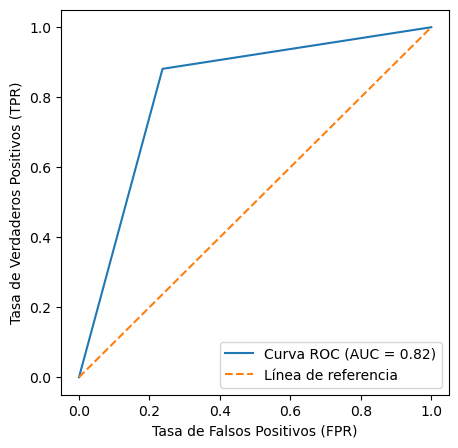




NAIVE BAYES - BoW NO ESTRATIFICADO
MATRIZ DE CONFUSIÓN
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    103     ------------------------     129    -----
--------------------------------------------------------------------------------
-----Negativos--------------    119      ------------------------     167   -----
--------------------------------------------------------------------------------

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.46      0.44      0.45       232
           1       0.56      0.58      0.57       286

    accuracy                           0.52       518
   macro avg       0.51      0.51      0.51       518
weighted avg       0.52      0.52      0.52       518
 

CURVA ROC y AUC


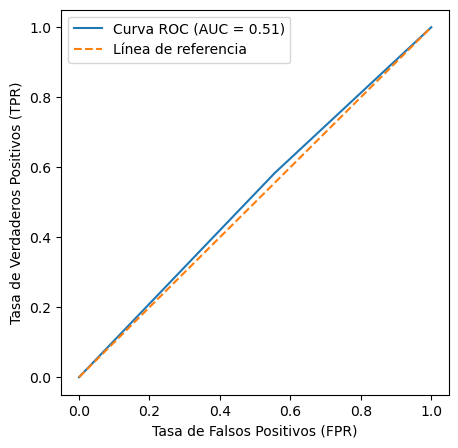

NAIVE BAYES - TF-IDF ESTRATIFICADO
MATRIZ DE CONFUSIÓN
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    173     ------------------------     59    -----
--------------------------------------------------------------------------------
-----Negativos--------------    24      ------------------------     262   -----
--------------------------------------------------------------------------------

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.88      0.75      0.81       232
           1       0.82      0.92      0.86       286

    accuracy                           0.84       518
   macro avg       0.85      0.83      0.83       518
weighted avg       0.84      0.84      0.84       518
 

CURVA ROC y AUC


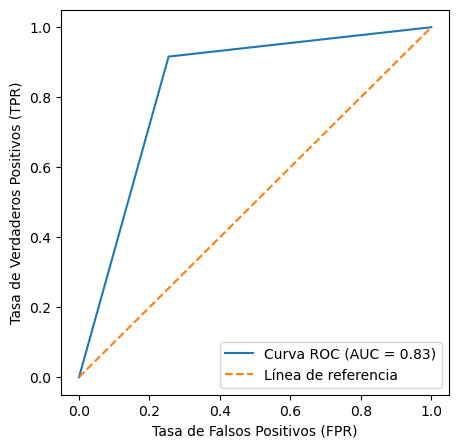




NAIVE BAYES - TF-IDF NO ESTRATIFICADO
MATRIZ DE CONFUSIÓN
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    90     ------------------------     142    -----
--------------------------------------------------------------------------------
-----Negativos--------------    113      ------------------------     173   -----
--------------------------------------------------------------------------------

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.44      0.39      0.41       232
           1       0.55      0.60      0.58       286

    accuracy                           0.51       518
   macro avg       0.50      0.50      0.49       518
weighted avg       0.50      0.51      0.50       518
 

CURVA ROC y AUC


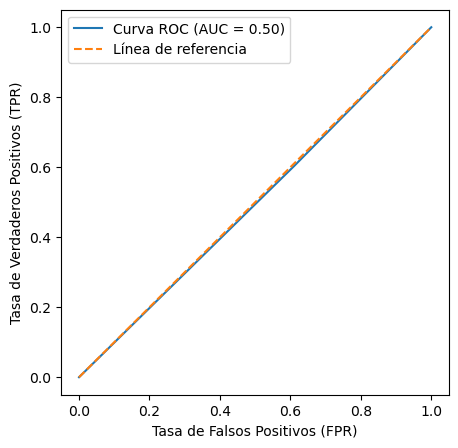

In [83]:
def naive_bayes(X_train, y_train, X_test):

    modelo = MultinomialNB() # Creación del modelo

    modelo.fit(X_train, y_train) # Entrenamiento

    y_pred = modelo.predict(X_test) # Evaluación de test

    return y_pred

# Bag Of Words
# 1. BoW Estratificado
print("NAIVE BAYES - BoW ESTRATIFICADO")
y_pred = naive_bayes(X_train_bow_estr, y_train_estratificado, X_test_bow_estr)
evaluacion_modelos(y_pred, y_test_estratificado)
print("\n\n")
# 2. BoW No Estratificado
print("NAIVE BAYES - BoW NO ESTRATIFICADO")
y_pred = naive_bayes(X_train_bow_noestr, y_train_no_estratificado, X_test_bow_noestr)
evaluacion_modelos(y_pred, y_test_estratificado)

# TF-IDF
# 1. TF-IDF Estratificado
print("NAIVE BAYES - TF-IDF ESTRATIFICADO")
y_pred = naive_bayes(X_train_tfidf_estr, y_train_estratificado, X_test_tfidf_estr)
evaluacion_modelos(y_pred, y_test_estratificado)
print("\n\n")
# 2. TF-IDF No Estratificado
print("NAIVE BAYES - TF-IDF NO ESTRATIFICADO")
y_pred = naive_bayes(X_train_tfidf_noestr, y_train_no_estratificado, X_test_tfidf_noestr)
evaluacion_modelos(y_pred, y_test_estratificado)

### **4.2. Regresión Logística**

REGRESIÓN LOGÍSTICA - BoW ESTRATIFICADO
MATRIZ DE CONFUSIÓN
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    171     ------------------------     61    -----
--------------------------------------------------------------------------------
-----Negativos--------------    29      ------------------------     257   -----
--------------------------------------------------------------------------------

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.85      0.74      0.79       232
           1       0.81      0.90      0.85       286

    accuracy                           0.83       518
   macro avg       0.83      0.82      0.82       518
weighted avg       0.83      0.83      0.82       518
 

CURVA ROC y AUC


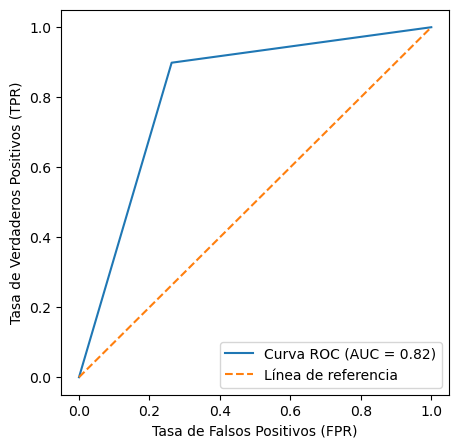




REGRESIÓN LOGÍSTICA - BoW NO ESTRATIFICADO
MATRIZ DE CONFUSIÓN
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    93     ------------------------     139    -----
--------------------------------------------------------------------------------
-----Negativos--------------    121      ------------------------     165   -----
--------------------------------------------------------------------------------

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.43      0.40      0.42       232
           1       0.54      0.58      0.56       286

    accuracy                           0.50       518
   macro avg       0.49      0.49      0.49       518
weighted avg       0.49      0.50      0.50       518
 

CURVA ROC y

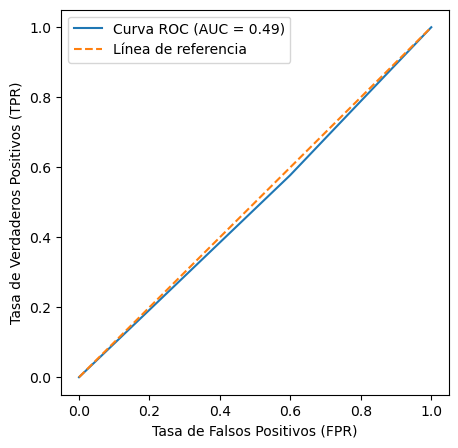

REGRESIÓN LOGÍSTICA - TF-IDF ESTRATIFICADO
MATRIZ DE CONFUSIÓN
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    165     ------------------------     67    -----
--------------------------------------------------------------------------------
-----Negativos--------------    22      ------------------------     264   -----
--------------------------------------------------------------------------------

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.88      0.71      0.79       232
           1       0.80      0.92      0.86       286

    accuracy                           0.83       518
   macro avg       0.84      0.82      0.82       518
weighted avg       0.84      0.83      0.83       518
 

CURVA ROC y AUC

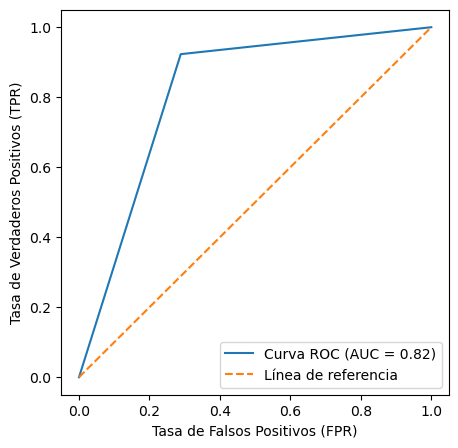




REGRESIÓN LOGÍSTICA - TF-IDF NO ESTRATIFICADO
MATRIZ DE CONFUSIÓN
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    88     ------------------------     144    -----
--------------------------------------------------------------------------------
-----Negativos--------------    113      ------------------------     173   -----
--------------------------------------------------------------------------------

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.44      0.38      0.41       232
           1       0.55      0.60      0.57       286

    accuracy                           0.50       518
   macro avg       0.49      0.49      0.49       518
weighted avg       0.50      0.50      0.50       518
 

CURVA RO

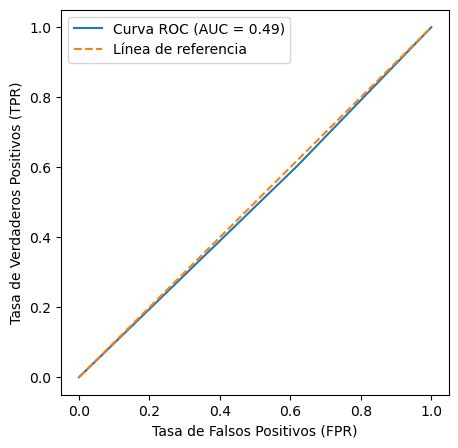

In [84]:
def regresion_log(X_train, y_train, X_test):

    modelo = LogisticRegression() # Creación del modelo

    modelo.fit(X_train, y_train) # Entrenamiento

    y_pred = modelo.predict(X_test) # Evaluación de test

    return y_pred

# Bag Of Words
# 1. BoW Estratificado
print("REGRESIÓN LOGÍSTICA - BoW ESTRATIFICADO")
y_pred = regresion_log(X_train_bow_estr, y_train_estratificado, X_test_bow_estr)
evaluacion_modelos(y_pred, y_test_estratificado)
print("\n\n")
# 2. BoW No Estratificado
print("REGRESIÓN LOGÍSTICA - BoW NO ESTRATIFICADO")
y_pred = regresion_log(X_train_bow_noestr, y_train_no_estratificado, X_test_bow_noestr)
evaluacion_modelos(y_pred, y_test_estratificado)

# TF-IDF
# 1. TF-IDF Estratificado
print("REGRESIÓN LOGÍSTICA - TF-IDF ESTRATIFICADO")
y_pred = regresion_log(X_train_tfidf_estr, y_train_estratificado, X_test_tfidf_estr)
evaluacion_modelos(y_pred, y_test_estratificado)
print("\n\n")
# 2. TF-IDF No Estratificado
print("REGRESIÓN LOGÍSTICA - TF-IDF NO ESTRATIFICADO")
y_pred = regresion_log(X_train_tfidf_noestr, y_train_no_estratificado, X_test_tfidf_noestr)
evaluacion_modelos(y_pred, y_test_estratificado)

### **4.3. Random Forest** 

RANDOM FOREST - BoW ESTRATIFICADO
MATRIZ DE CONFUSIÓN
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    177     ------------------------     55    -----
--------------------------------------------------------------------------------
-----Negativos--------------    46      ------------------------     240   -----
--------------------------------------------------------------------------------

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       232
           1       0.81      0.84      0.83       286

    accuracy                           0.81       518
   macro avg       0.80      0.80      0.80       518
weighted avg       0.80      0.81      0.80       518
 

CURVA ROC y AUC


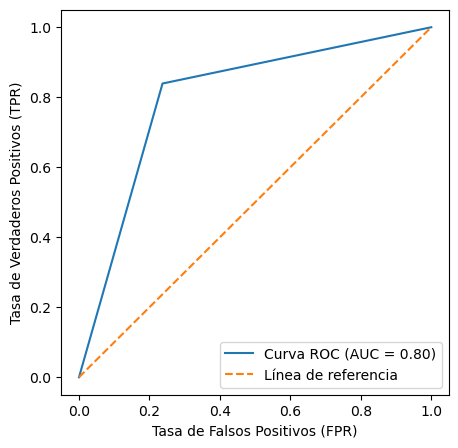




RANDOM FOREST - BoW NO ESTRATIFICADO
MATRIZ DE CONFUSIÓN
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    191     ------------------------     39    -----
--------------------------------------------------------------------------------
-----Negativos--------------    47      ------------------------     241   -----
--------------------------------------------------------------------------------

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       230
           1       0.86      0.84      0.85       288

    accuracy                           0.83       518
   macro avg       0.83      0.83      0.83       518
weighted avg       0.83      0.83      0.83       518
 

CURVA ROC y AUC


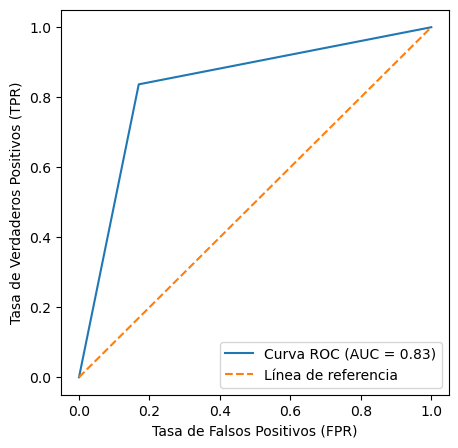

RANDOM FOREST - TF-IDF ESTRATIFICADO
MATRIZ DE CONFUSIÓN
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    183     ------------------------     49    -----
--------------------------------------------------------------------------------
-----Negativos--------------    26      ------------------------     260   -----
--------------------------------------------------------------------------------

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.88      0.79      0.83       232
           1       0.84      0.91      0.87       286

    accuracy                           0.86       518
   macro avg       0.86      0.85      0.85       518
weighted avg       0.86      0.86      0.85       518
 

CURVA ROC y AUC


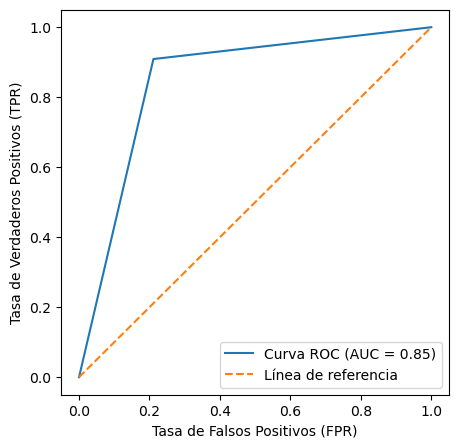




RANDOM FOREST - TF-IDF NO ESTRATIFICADO
MATRIZ DE CONFUSIÓN
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    182     ------------------------     48    -----
--------------------------------------------------------------------------------
-----Negativos--------------    28      ------------------------     260   -----
--------------------------------------------------------------------------------

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       230
           1       0.84      0.90      0.87       288

    accuracy                           0.85       518
   macro avg       0.86      0.85      0.85       518
weighted avg       0.85      0.85      0.85       518
 

CURVA ROC y AUC

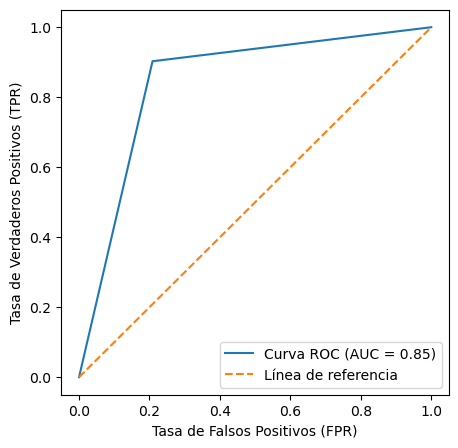

In [85]:
def random_forest(X_train, y_train, X_test):

    modelo = RandomForestClassifier() # Creación del modelo

    modelo.fit(X_train, y_train) # Entrenamiento

    y_pred = modelo.predict(X_test) # Evaluación de test

    return y_pred

# Bag Of Words
# 1. BoW Estratificado
print("RANDOM FOREST - BoW ESTRATIFICADO")
y_pred = random_forest(X_train_bow_estr, y_train_estratificado, X_test_bow_estr)
evaluacion_modelos(y_pred, y_test_estratificado)
print("\n\n")
# 2. BoW No Estratificado
print("RANDOM FOREST - BoW NO ESTRATIFICADO")
y_pred = random_forest(X_train_bow_noestr, y_train_no_estratificado, X_test_bow_noestr)
evaluacion_modelos(y_pred, y_test_no_estratificado)

# TF-IDF
# 1. TF-IDF Estratificado
print("RANDOM FOREST - TF-IDF ESTRATIFICADO")
y_pred = random_forest(X_train_tfidf_estr, y_train_estratificado, X_test_tfidf_estr)
evaluacion_modelos(y_pred, y_test_estratificado)
print("\n\n")
# 2. TF-IDF No Estratificado
print("RANDOM FOREST - TF-IDF NO ESTRATIFICADO")
y_pred = random_forest(X_train_tfidf_noestr, y_train_no_estratificado, X_test_tfidf_noestr)
evaluacion_modelos(y_pred, y_test_no_estratificado)

# ****5. Evaluación mediante validación cruzada****

Tras la realización de los modelos y, su evaluación a través de la técnica de retención (80/20), realizaremos el mismo análisis pero, esta vez, realizando la evaluación con `validación cruzada` (cross-validation) mediante `StratifiedKFold`.

In [86]:
# Definimos el objeto de validación cruzada estratificada con 10 folds, barajado y con semilla fija para reproducibilidad
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

VALIDACIÓN CRUZADA - NAIVE BAYES - BoW ESTRATIFICADO
MATRIZ DE CONFUSIÓN TOTAL ACUMULADA EN VALIDACIÓN CRUZADA
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    778     ------------------------     150    ----
--------------------------------------------------------------------------------
-----Negativos--------------    154      ------------------------     990   ----
--------------------------------------------------------------------------------

CURVA ROC y AUC TOTAL EN VALIDACIÓN CRUZADA


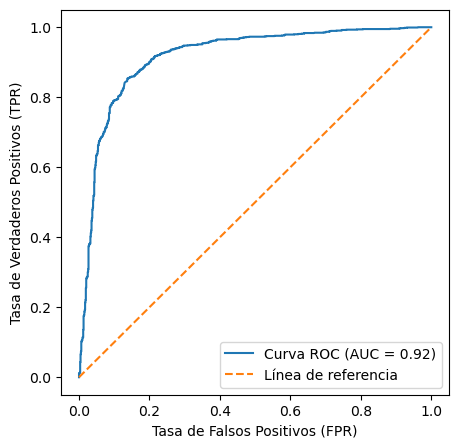

MÉTRICAS ACCURACY, PRECISION, RECALL Y F1-SCORE EN VALIDACIÓN CRUZADA
Accuracy promedio y desviación estándar: 0.8533 ± 0.0333
Precision promedio y desviación estándar: 0.8690 ± 0.0313
Recall promedio y desviación estándar: 0.8654 ± 0.0406
F1-Score promedio y desviación estándar: 0.8668 ± 0.0307



VALIDACIÓN CRUZADA - REGRESIÓN LOGÍSTICA - BoW ESTRATIFICADO
MATRIZ DE CONFUSIÓN TOTAL ACUMULADA EN VALIDACIÓN CRUZADA
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    770     ------------------------     158    ----
--------------------------------------------------------------------------------
-----Negativos--------------    106      ------------------------     1038   ----
--------------------------------------------------------------------------------

CURVA ROC y 

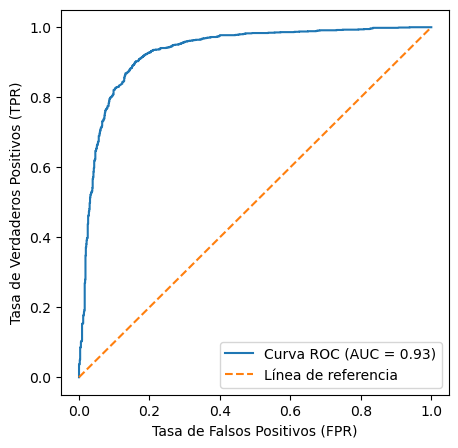

MÉTRICAS ACCURACY, PRECISION, RECALL Y F1-SCORE EN VALIDACIÓN CRUZADA
Accuracy promedio y desviación estándar: 0.8726 ± 0.0215
Precision promedio y desviación estándar: 0.8683 ± 0.0212
Recall promedio y desviación estándar: 0.9074 ± 0.0247
F1-Score promedio y desviación estándar: 0.8872 ± 0.0188



VALIDACIÓN CRUZADA - RANDOM FOREST - BoW ESTRATIFICADO
MATRIZ DE CONFUSIÓN TOTAL ACUMULADA EN VALIDACIÓN CRUZADA
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    794     ------------------------     134    ----
--------------------------------------------------------------------------------
-----Negativos--------------    159      ------------------------     985   ----
--------------------------------------------------------------------------------

CURVA ROC y AUC TOT

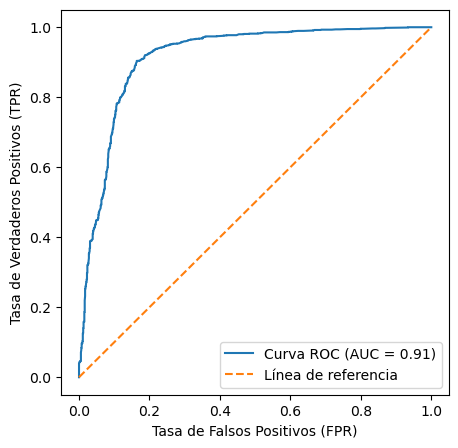

MÉTRICAS ACCURACY, PRECISION, RECALL Y F1-SCORE EN VALIDACIÓN CRUZADA
Accuracy promedio y desviación estándar: 0.8586 ± 0.0226
Precision promedio y desviación estándar: 0.8812 ± 0.0299
Recall promedio y desviación estándar: 0.8610 ± 0.0197
F1-Score promedio y desviación estándar: 0.8707 ± 0.0195



VALIDACIÓN CRUZADA - NAIVE BAYES - TF-IDF ESTRATIFICADO
MATRIZ DE CONFUSIÓN TOTAL ACUMULADA EN VALIDACIÓN CRUZADA
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    736     ------------------------     192    ----
--------------------------------------------------------------------------------
-----Negativos--------------    95      ------------------------     1049   ----
--------------------------------------------------------------------------------

CURVA ROC y AUC TO

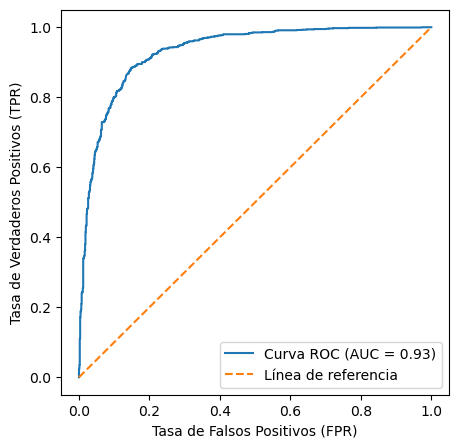

MÉTRICAS ACCURACY, PRECISION, RECALL Y F1-SCORE EN VALIDACIÓN CRUZADA
Accuracy promedio y desviación estándar: 0.8615 ± 0.0300
Precision promedio y desviación estándar: 0.8458 ± 0.0274
Recall promedio y desviación estándar: 0.9170 ± 0.0341
F1-Score promedio y desviación estándar: 0.8797 ± 0.0262



VALIDACIÓN CRUZADA - REGRESIÓN LOGÍSTICA - TF-IDF ESTRATIFICADO
MATRIZ DE CONFUSIÓN TOTAL ACUMULADA EN VALIDACIÓN CRUZADA
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    707     ------------------------     221    ----
--------------------------------------------------------------------------------
-----Negativos--------------    86      ------------------------     1058   ----
--------------------------------------------------------------------------------

CURVA ROC 

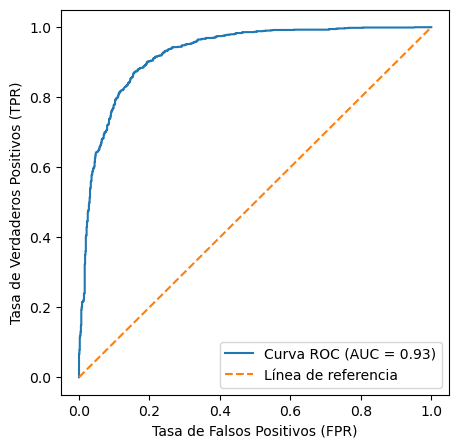

MÉTRICAS ACCURACY, PRECISION, RECALL Y F1-SCORE EN VALIDACIÓN CRUZADA
Accuracy promedio y desviación estándar: 0.8518 ± 0.0269
Precision promedio y desviación estándar: 0.8278 ± 0.0268
Recall promedio y desviación estándar: 0.9249 ± 0.0234
F1-Score promedio y desviación estándar: 0.8735 ± 0.0221



VALIDACIÓN CRUZADA - RANDOM FOREST - TF-IDF ESTRATIFICADO
MATRIZ DE CONFUSIÓN TOTAL ACUMULADA EN VALIDACIÓN CRUZADA
--------------------------------------------------------------------------------
-----Valores Predichos------------------------Valores Reales--------------------
---------------------------- Verdaderos ------------------------ Negativos -----
-----Verdaderos-------------    748     ------------------------     180    ----
--------------------------------------------------------------------------------
-----Negativos--------------    87      ------------------------     1057   ----
--------------------------------------------------------------------------------

CURVA ROC y AUC 

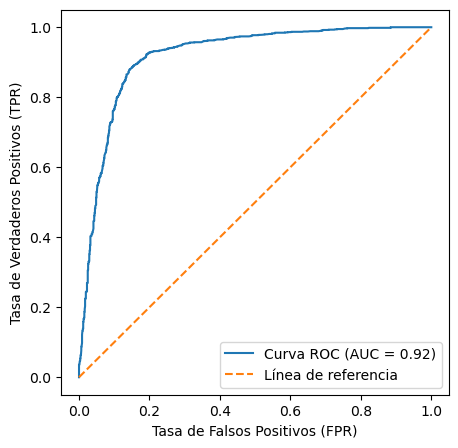

MÉTRICAS ACCURACY, PRECISION, RECALL Y F1-SCORE EN VALIDACIÓN CRUZADA
Accuracy promedio y desviación estándar: 0.8711 ± 0.0191
Precision promedio y desviación estándar: 0.8550 ± 0.0211
Recall promedio y desviación estándar: 0.9240 ± 0.0218
F1-Score promedio y desviación estándar: 0.8879 ± 0.0161


In [91]:
def validacion_cruzada(modelo, X, y, cv):

    matriz_confusion_total = np.zeros((2, 2), dtype=int)
    y_pred_total = []
    y_test_total = []
    accuracy_total = []
    precision_total = []
    recall_total = []
    f1_total = []

    for train_index, test_index in cv.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict_proba(X_test)[:, 1]  # Usamos la probabilidad de la clase positiva

        # Acumulamos la matriz de confusión
        y_pred_binaria = (y_pred > 0.5).astype(int)
        cm = confusion_matrix(y_test, y_pred_binaria)
        matriz_confusion_total += cm

        # Acumulamos las predicciones y los valores reales para el reporte final del ROC y AUC
        y_pred_total.extend(y_pred)
        y_test_total.extend(y_test)

        # Acumulamos métricas Accuracy, Precision, Recall y F1-Score para cada fold

        accuracy_total.append(accuracy_score(y_test, y_pred_binaria))
        precision_total.append(precision_score(y_test, y_pred_binaria))
        recall_total.append(recall_score(y_test, y_pred_binaria))
        f1_total.append(f1_score(y_test, y_pred_binaria))

    print("MATRIZ DE CONFUSIÓN TOTAL ACUMULADA EN VALIDACIÓN CRUZADA")
    print("--------------------------------------------------------------------------------")
    print("-----Valores Predichos------------------------Valores Reales--------------------")
    print("---------------------------- Verdaderos ------------------------ Negativos -----")
    print(f"-----Verdaderos-------------    {matriz_confusion_total[0,0]}     ------------------------     {matriz_confusion_total[0,1]}    ----")
    print("--------------------------------------------------------------------------------")
    print(f"-----Negativos--------------    {matriz_confusion_total[1,0]}      ------------------------     {matriz_confusion_total[1,1]}   ----")
    print("--------------------------------------------------------------------------------\n")

    print("CURVA ROC y AUC TOTAL EN VALIDACIÓN CRUZADA")
    fpr, tpr, _ = roc_curve(y_test_total, y_pred_total)
    auc = roc_auc_score(y_test_total, y_pred_total)
    plt.figure(figsize=(5,5))
    plt.xlabel("Tasa de Falsos Positivos (FPR)")
    plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
    plt.plot(fpr, tpr, label=f"Curva ROC (AUC = {auc:.2f})")
    plt.plot([0,1], [0,1], linestyle="--", label="Línea de referencia")
    plt.legend()
    plt.show()

    print("MÉTRICAS ACCURACY, PRECISION, RECALL Y F1-SCORE EN VALIDACIÓN CRUZADA")
    print(f"Accuracy promedio y desviación estándar: {np.mean(accuracy_total):.4f} ± {np.std(accuracy_total):.4f}")
    print(f"Precision promedio y desviación estándar: {np.mean(precision_total):.4f} ± {np.std(precision_total):.4f}")
    print(f"Recall promedio y desviación estándar: {np.mean(recall_total):.4f} ± {np.std(recall_total):.4f}")
    print(f"F1-Score promedio y desviación estándar: {np.mean(f1_total):.4f} ± {np.std(f1_total):.4f}")


# Bag Of Words
# 1. Naive Bayes - BoW Estratificado
print("VALIDACIÓN CRUZADA - NAIVE BAYES - BoW ESTRATIFICADO")
validacion_cruzada(MultinomialNB(), X_train_bow_estr, y_train_estratificado, cv)
print("\n\n")
# 2. Regresión logística - BoW Estratificado
print("VALIDACIÓN CRUZADA - REGRESIÓN LOGÍSTICA - BoW ESTRATIFICADO")
validacion_cruzada(LogisticRegression(random_state=42), X_train_bow_estr, y_train_estratificado, cv)
print("\n\n")
# 3. Random Forest - BoW Estratificado
print("VALIDACIÓN CRUZADA - RANDOM FOREST - BoW ESTRATIFICADO")
validacion_cruzada(RandomForestClassifier(random_state=42), X_train_bow_estr, y_train_estratificado, cv)
print("\n\n")

# TF-IDF
# 1. Naive Bayes - TF-IDF Estratificado
print("VALIDACIÓN CRUZADA - NAIVE BAYES - TF-IDF ESTRATIFICADO")
validacion_cruzada(MultinomialNB(), X_train_tfidf_estr, y_train_estratificado, cv)
print("\n\n")
# 2. Regresión logística - TF-IDF Estratificado
print("VALIDACIÓN CRUZADA - REGRESIÓN LOGÍSTICA - TF-IDF ESTRATIFICADO")
validacion_cruzada(LogisticRegression(random_state=42), X_train_tfidf_estr, y_train_estratificado, cv)
print("\n\n")
# 3. Random Forest - TF-IDF Estratificado
print("VALIDACIÓN CRUZADA - RANDOM FOREST - TF-IDF ESTRATIFICADO")
validacion_cruzada(RandomForestClassifier(random_state=42), X_train_tfidf_estr, y_train_estratificado, cv)

In [88]:
# 5.Evaluación mediante validación cruzada (varias celdas)
'''
- En una celda, Definición  del  esquema  de  validación  cruzada,  especificando  el 
número de particiones (k) y el uso de estratificación.

- En otra celda, Para cada técnica de representación (BoW y TF-IDF) y para los tres 
modelos definidos en el apartado anterior (Entrenamiento y evaluacion de modelos), se deberá: 
    •  Entrenar el modelo en cada fold. 
    • Evaluarlo sobre el subconjunto correspondiente de validación. 
    • Almacenar las métricas obtenidas en cada iteración. 
Se  valorará  nuevamente  el  uso  de  estructuras  de  control  (bucles, 
funciones, etc.) que eviten la repetición innecesaria de código

- En otra celda, Presentación de resultados agregados, incluyendo: 
    1. Matriz de confusión acumulada entre folds. 
    2. Curva ROC y AUC acumulada. 
    3. Media y desviación estándar de las métricas de rendimiento 
    (Accuracy, Precision, Recall y F1-score) a lo largo de los folds

'''

'\n- En una celda, Definición  del  esquema  de  validación  cruzada,  especificando  el \nnúmero de particiones (k) y el uso de estratificación.\n\n- En otra celda, Para cada técnica de representación (BoW y TF-IDF) y para los tres \nmodelos definidos en el apartado anterior (Entrenamiento y evaluacion de modelos), se deberá: \n    •  Entrenar el modelo en cada fold. \n    • Evaluarlo sobre el subconjunto correspondiente de validación. \n    • Almacenar las métricas obtenidas en cada iteración. \nSe  valorará  nuevamente  el  uso  de  estructuras  de  control  (bucles, \nfunciones, etc.) que eviten la repetición innecesaria de código\n\n- En otra celda, Presentación de resultados agregados, incluyendo: \n    1. Matriz de confusión acumulada entre folds. \n    2. Curva ROC y AUC acumulada. \n    3. Media y desviación estándar de las métricas de rendimiento \n    (Accuracy, Precision, Recall y F1-score) a lo largo de los folds\n\n'

In [89]:
#6 Discusión y análisis de resultados (varias celdas)

'''
- EN una celda,  Representación del texto y número de términos 

    • Indique el número de términos utilizados en la representación final y 
    justifique brevemente la configuración elegida (n-gramas, frecuencia 
    mínima, número máximo de características, etc.). 
     
    • Comente cómo ha influido el tamaño del vocabulario en el 
    rendimiento del modelo y si ha observado mejoras al modificar estos 
    parámetros.
    
    
- En otra celda, Mejor resultado obtenido y comportamiento del modelo 
Indique cuál ha sido el mejor resultado alcanzado en el esquema 
80/20, especificando: 
    • Técnica de vectorización utilizada. 
    • Modelo empleado. 
    • Analice brevemente el comportamiento del modelo a partir de la 
    matriz de confusión, señalando si existe mayor dificultad en alguna 
    de las clases y qué tipo de errores son más frecuentes.
    
    
- En otra celda, Estabilidad y límite del rendimiento 
Compare el resultado del esquema 80/20 con el obtenido mediante 
validación cruzada. 
    • ¿Se mantiene un rendimiento similar? 
    • ¿Puede considerarse el modelo estable? 
    • Finalmente, reflexione si podría alcanzar una precisión cercana al 
    90% con los datos actuales, justificando su respuesta de manera 
    argumentada.

'''

'\n- EN una celda,  Representación del texto y número de términos \n\n    • Indique el número de términos utilizados en la representación final y \n    justifique brevemente la configuración elegida (n-gramas, frecuencia \n    mínima, número máximo de características, etc.). \n     \n    • Comente cómo ha influido el tamaño del vocabulario en el \n    rendimiento del modelo y si ha observado mejoras al modificar estos \n    parámetros.\n    \n    \n- En otra celda, Mejor resultado obtenido y comportamiento del modelo \nIndique cuál ha sido el mejor resultado alcanzado en el esquema \n80/20, especificando: \n    • Técnica de vectorización utilizada. \n    • Modelo empleado. \n    • Analice brevemente el comportamiento del modelo a partir de la \n    matriz de confusión, señalando si existe mayor dificultad en alguna \n    de las clases y qué tipo de errores son más frecuentes.\n    \n    \n- En otra celda, Estabilidad y límite del rendimiento \nCompare el resultado del esquema 80/20 con

In [90]:
# 7 Bonus Track (Opcional): Interpretabilidad del modelo mediante LIME (1 celda)

'''
- Aplicar LIME para explicar al menos cinco instancias del conjunto de 
test, incluyendo: 
    • Dos correctamente clasificadas como positivas. 
    • Dos correctamente clasificadas como negativas. 
    • Una instancia mal clasificada.
    

- Para cada explicación, identificar: 
    • Los términos que más contribuyen a la predicción positiva. 
    • Los términos que más contribuyen a la predicción negativa. 
    • La probabilidad estimada por el modelo para cada clase.
    

- Analizar críticamente: 
    • Si las palabras más influyentes son coherentes desde el punto de 
    vista semántico. 
    • Si existen términos espurios del preprocesamiento que estén 
    influyendo en la decisión. 
    • Otros factores que puedan ser relevantes.
'''

'\n- Aplicar LIME para explicar al menos cinco instancias del conjunto de \ntest, incluyendo: \n    • Dos correctamente clasificadas como positivas. \n    • Dos correctamente clasificadas como negativas. \n    • Una instancia mal clasificada.\n    \n\n- Para cada explicación, identificar: \n    • Los términos que más contribuyen a la predicción positiva. \n    • Los términos que más contribuyen a la predicción negativa. \n    • La probabilidad estimada por el modelo para cada clase.\n    \n\n- Analizar críticamente: \n    • Si las palabras más influyentes son coherentes desde el punto de \n    vista semántico. \n    • Si existen términos espurios del preprocesamiento que estén \n    influyendo en la decisión. \n    • Otros factores que puedan ser relevantes.\n'